In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from src.fitness import compute_cv_fitness
from src.sa_optimizer import simulated_annealing
from src.ga_optimizer import genetic_algorithm

import importlib
import src.fitness as fitness
import src.sa_optimizer as sa_opt
import src.ga_optimizer as ga_opt

importlib.reload(fitness)
importlib.reload(sa_opt)
importlib.reload(ga_opt)

<module 'src.ga_optimizer' from 'C:\\Users\\sumra\\school_work\\research_paper\\src\\ga_optimizer.py'>

In [4]:
# Load & prepare data
df = pd.read_csv('data/all_high_risk.csv')
df

,Unnamed: 0,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,...,total_error_rate,service_failure_ratio,login_attempt_score,host_connection_diversity,security_risk_score,risk_level,if_prediction,if_anomaly_score,hybrid_risk_score,hybrid_risk_level
0,0,25950,tcp,private,RSTR,1,0,0,0,0,...,1.0,0,0,255.0,0.1,Low,-1,0.742674,0.324936,Medium
1,1,0,tcp,ftp_data,SF,14416,0,0,0,0,...,0.0,0,0,205.0,0.4,High/Critical,1,0.163606,0.317262,Medium
2,2,36613,tcp,private,RSTR,1,0,0,0,0,...,1.0,0,0,255.0,0.1,Low,-1,0.775548,0.336442,Medium
3,3,0,tcp,ftp_data,SF,10389,0,0,0,0,...,0.0,0,0,255.0,0.4,High/Critical,1,0.123366,0.303178,Medium
4,4,0,tcp,http,SF,54540,8314,0,0,0,...,0.0,0,0,251.0,0.4,High/Critical,-1,0.421064,0.407372,High/Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4391,4426,0,tcp,http,SF,54540,8314,0,0,0,...,0.0,0,0,275.0,0.4,High/Critical,1,0.305733,0.367007,Medium
4392,4427,0,tcp,smtp,SF,5603,333,0,0,0,...,0.0,0,0,119.0,0.4,High/Critical,1,0.351034,0.382862,Medium
4393,4428,3,tcp,ftp_data,SF,2194619,0,0,0,0,...,0.0,0,0,255.0,0.4,High/Critical,-1,0.511293,0.438952,High/Critical
4394,4429,0,tcp,http,SF,54540,8314,0,0,0,...,0.0,0,0,272.0,0.4,High/Critical,1,0.305733,0.367007,Medium


In [5]:
df["attack"].unique()

array(['portsweep', 'normal', 'back', 'teardrop', 'satan', 'warezclient',
       'buffer_overflow', 'guess_passwd', 'mailbomb', 'apache2', 'xterm'],
      dtype=object)

In [6]:
# Selected features from previous work
classification_features = [
    'src_bytes', 'dst_bytes', 
    'duration', 'serror_rate', 'rerror_rate',
    'num_failed_logins', 'root_shell'
]

In [8]:
# Make sure X values are numerical values
# Create binary label for SA and GA
X = df[classification_features].copy().values.astype(float)
y = (df['attack'] != 'normal').astype(int).values  # 1 = attack, 0 = normal

In [9]:
# Check if done correctly
print(f"✅ Data ready! X shape: {X.shape}, y unique labels: {np.unique(y)}")

✅ Data ready! X shape: (4396, 7), y unique labels: [0 1]


In [10]:
# Define fitness function using baseline model
def evaluate_threshold(thresh):
    return compute_cv_fitness(thresh, X, y, RandomForestClassifier, n_splits=5)

In [11]:
# Run SA
print("Running Simulated Annealing...")
sa_result = simulated_annealing(
    fitness_fn=evaluate_threshold, threshold_range=(0.4, 0.85), n_iterations=1000, seed=123, 
    initial_temp=1.0, cooling_rate=0.99
)
print("...Finished!")

Running Simulated Annealing...
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 0
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 1
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 2
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 3
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 4
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 5
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 6
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 7
Running fitness fucntion...
...Process complete!
--------------------------------

In [12]:
print(sa_result["best_threshold"])
print(sa_result["best_fitness"])

0.5210437333981411
0.9963606231496513


In [17]:
# Run GA
print("Running Genetic Algorithm...")
ga_result = genetic_algorithm(
    fitness_fn=evaluate_threshold, pop_size=35, threshold_range=(0.4, 0.85),
    n_generations=200, crossover_rate=0.8, mutation_rate=0.1, seed=42
)
print("#"*40)
print("...Finished!")
print("#"*40)

Running Genetic Algorithm...
----------------------------------------
Current Generation: 0
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion...
...Process complete!
Running fitness fucntion..

In [18]:
# Log results into a DataFrame
results_df = pd.DataFrame({
    'Algorithm': ['SA', 'GA'],
    'Best Threshold': [sa_result['best_threshold'], ga_result['best_threshold']],
    'CV F1-Macro': [sa_result['best_fitness'], ga_result['best_fitness']]
})

In [19]:
results_df

,Algorithm,Best Threshold,CV F1-Macro
0,SA,0.521044,0.996361
1,GA,0.545979,0.995906


High F1 scores on NIDS data can sometimes indicate leakage or overly optimistic splits. We run this 5-line validation block to confirm results are robust:

In [53]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_05 = cross_val_score(RandomForestClassifier(random_state=42), X, y_binary, 
                            cv=skf, scoring='f1_macro', n_jobs=-1)
print(f"Fixed threshold (0.5) CV F1: {scores_05.mean():.4f} ± {scores_05.std():.4f}")

# Check class balance impact on macro-F1
from sklearn.metrics import precision_recall_fscore_support
rf = RandomForestClassifier(random_state=42).fit(X, y_binary)
proba_all = rf.predict_proba(X)[:, 1]
preds = (proba_all >= 0.5).astype(int)
print("\nPer-class F1:", precision_recall_fscore_support(y_binary, preds, average=None)[2])

Fixed threshold (0.5) CV F1: 0.9959 ± 0.0023

Per-class F1: [0.99976953 0.99977543]


In [75]:
sa_hist = pd.DataFrame(sa_result['history'])
sa_hist.head()

,iter,threshold,fitness,accepted
0,0,0.688669,0.994085,True
1,1,0.698368,0.992948,True
2,2,0.727223,0.993175,True
3,3,0.695400,0.993858,True
4,4,0.722497,0.993175,True


In [72]:
sa_hist['threshold'].iloc[145:160]

145    0.849397
146    0.780808
147    0.686686
148    0.754733
149    0.790531
150    0.850000
151    0.850000
152    0.844771
153    0.850000
154    0.707432
155    0.594868
156    0.554789
157    0.564743
158    0.571807
159    0.579129
Name: threshold, dtype: float64

In [67]:
ga_hist = pd.DataFrame(ga_result['history'])
ga_hist.head()

,gen,threshold,fitness,mean_fitness
0,0,0.604888,0.995906,0.993507
1,1,0.577618,0.995906,0.994150
2,2,0.522276,0.996361,0.994365
3,3,0.512276,0.995678,0.994339
4,4,0.647464,0.995678,0.994644


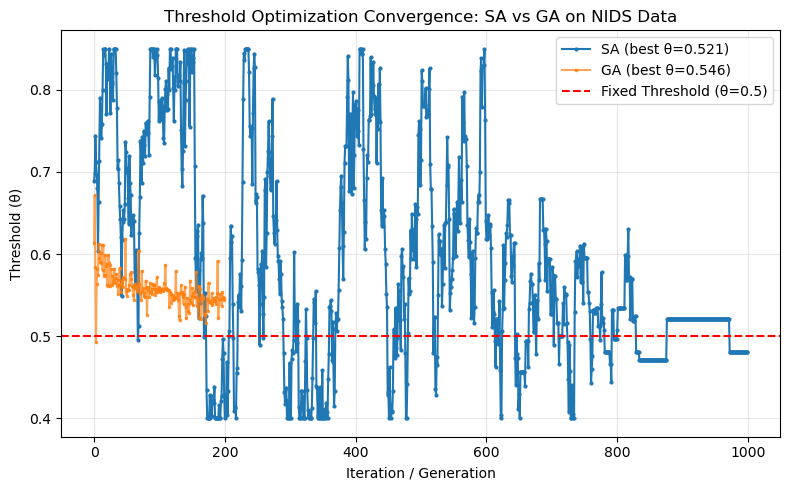

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Merge histories
sa_hist = pd.DataFrame(sa_result['history'])
ga_hist = pd.DataFrame(ga_result['history'])

plt.figure(figsize=(8,5))
plt.plot(sa_hist['iter'], sa_hist['threshold'], label='SA (best θ=0.521)', marker='o', markersize=2)
plt.plot(ga_hist['gen'], ga_hist['threshold'], label='GA (best θ=0.546)', marker='s', markersize=2, alpha=0.7)
plt.axhline(y=0.5, color='red', linestyle='--', label='Fixed Threshold (θ=0.5)')
plt.xlabel('Iteration / Generation'); 
plt.ylabel('Threshold (θ)')
plt.title('Threshold Optimization Convergence: SA vs GA on NIDS Data')
plt.legend(); plt.grid(alpha=0.3); 
plt.tight_layout()
plt.show()

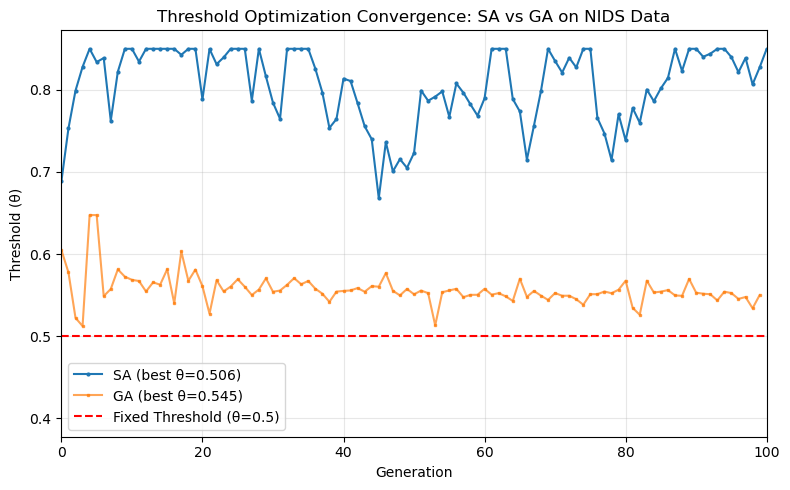

In [91]:
plt.figure(figsize=(8,5))
plt.plot(sa_hist['iter'], sa_hist['threshold'], label='SA (best θ=0.506)', marker='o', markersize=2)
plt.plot(ga_hist['gen'], ga_hist['threshold'], label='GA (best θ=0.545)', marker='s', markersize=2, alpha=0.7)
plt.axhline(y=0.5, color='red', linestyle='--', label='Fixed Threshold (θ=0.5)')
plt.xlabel('Generation'); 
plt.ylabel('Threshold (θ)')
plt.title('Threshold Optimization Convergence: SA vs GA on NIDS Data')
plt.legend();
plt.xlim(0, 100)
plt.grid(alpha=0.3); 
plt.tight_layout()
plt.show()

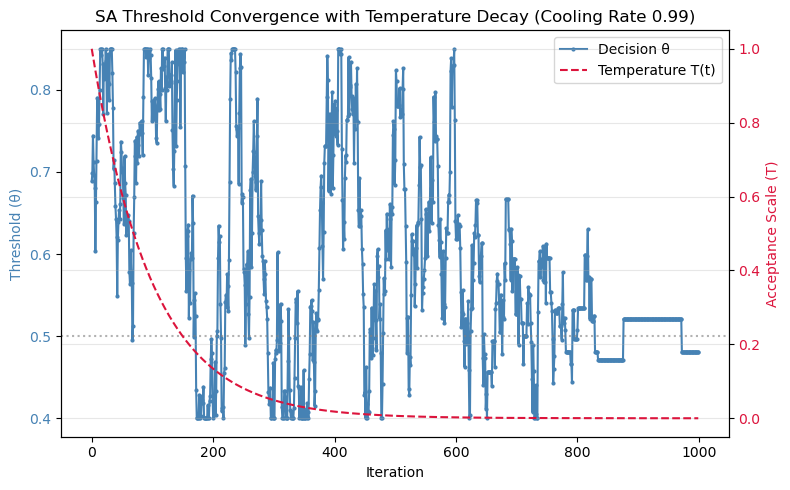

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

sa_hist = pd.DataFrame(sa_result['history'])

#Standardize column names (handles previous naming variations)
df = sa_hist.copy()
if 'iteration' in df.columns and 'iter' not in df.columns:
    df.rename(columns={'iteration': 'iter'}, inplace=True)

# 🔑 Parameters used during SA run (must match what you passed)
INITIAL_TEMP = 1.0
COOLING_RATE = 0.99

# Calculate temperature decay for each iteration
df['temp'] = INITIAL_TEMP * (COOLING_RATE ** df['iter'])

# Dual Y-axis plot: Threshold vs Temperature
fig, ax1 = plt.subplots(figsize=(8,5))

# Left axis: Threshold trajectory
ax1.plot(df['iter'], df['threshold'], color='steelblue', marker='o', markersize=2, linewidth=1.5, label='Decision θ')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Threshold (θ)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.axhline(y=0.5, color='gray', linestyle=':', alpha=0.6)

# Right axis: Temperature decay curve
ax2 = ax1.twinx()
ax2.plot(df['iter'], df['temp'], color='crimson', linestyle='--', linewidth=1.5, label='Temperature T(t)')
ax2.set_ylabel('Acceptance Scale (T)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('SA Threshold Convergence with Temperature Decay (Cooling Rate 0.99)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [95]:
sa_result_95 = simulated_annealing(
    fitness_fn=evaluate_threshold, threshold_range=(0.4, 0.85), n_iterations=500, seed=123, 
    initial_temp=1.0, cooling_rate=0.95
)

Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 0
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 1
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 2
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 3
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 4
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 5
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 6
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 7
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 8
R

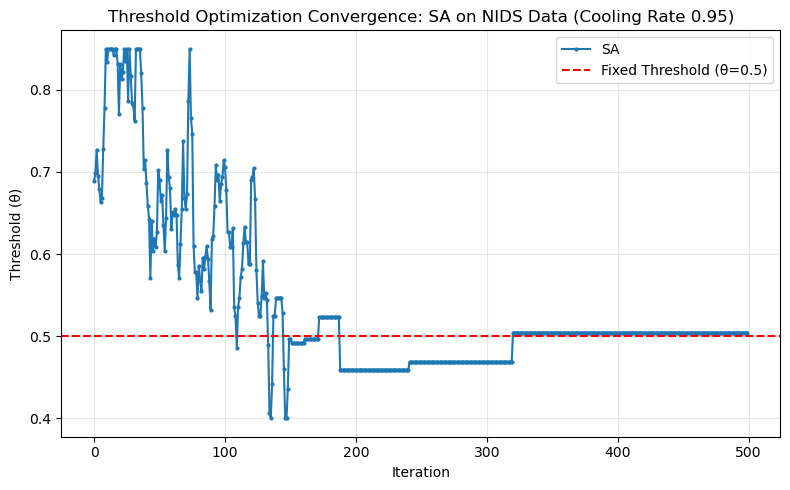

In [102]:
sa_hist_95 = pd.DataFrame(sa_result_95['history'])

plt.figure(figsize=(8,5))
plt.plot(sa_hist_95['iter'], sa_hist_95['threshold'], label='SA', marker='o', markersize=2)
plt.axhline(y=0.5, color='red', linestyle='--', label='Fixed Threshold (θ=0.5)')
plt.xlabel('Iteration'); 
plt.ylabel('Threshold (θ)')
plt.title('Threshold Optimization Convergence: SA on NIDS Data (Cooling Rate 0.95)')
plt.legend(); plt.grid(alpha=0.3); 
plt.tight_layout()
plt.show()

In [98]:
print(sa_result_95["best_threshold"])
print(sa_result_95["best_fitness"])

0.5043020055763335
0.9963606025315623


In [96]:
sa_result_90 = simulated_annealing(
    fitness_fn=evaluate_threshold, threshold_range=(0.4, 0.85), n_iterations=300, seed=123, 
    initial_temp=1.0, cooling_rate=0.90
)

Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 0
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 1
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 2
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 3
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 4
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 5
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 6
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 7
Running fitness fucntion...
...Process complete!
----------------------------------------
Current Iteration: 8
R

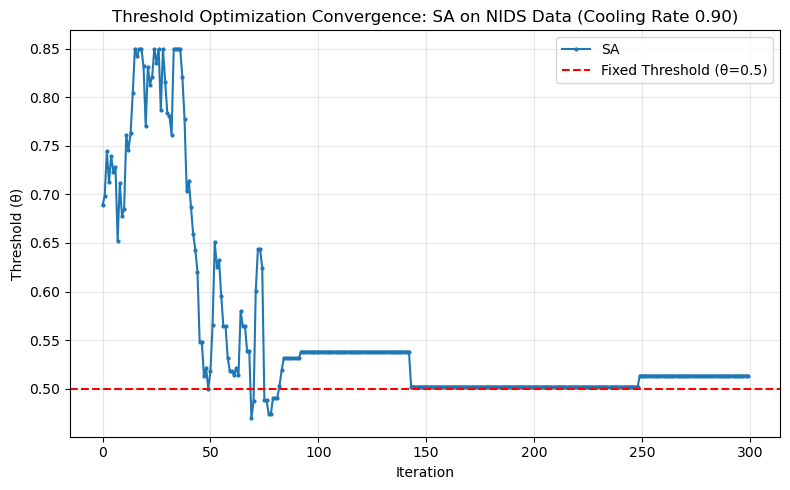

In [103]:
sa_hist_90 = pd.DataFrame(sa_result_90['history'])

plt.figure(figsize=(8,5))
plt.plot(sa_hist_90['iter'], sa_hist_90['threshold'], label='SA', marker='o', markersize=2)
plt.axhline(y=0.5, color='red', linestyle='--', label='Fixed Threshold (θ=0.5)')
plt.xlabel('Iteration'); 
plt.ylabel('Threshold (θ)')
plt.title('Threshold Optimization Convergence: SA on NIDS Data (Cooling Rate 0.90)')
plt.legend(); plt.grid(alpha=0.3); 
plt.tight_layout()
plt.show()

In [99]:
print(sa_result_90["best_threshold"])
print(sa_result_90["best_fitness"])

0.5314293199418202
0.9961330959909453


In [101]:
sa_hist_90

,iter,threshold,fitness,accepted
0,0,0.688669,0.993403,True
1,1,0.698368,0.993631,True
2,2,0.744379,0.993175,True
3,3,0.712556,0.993175,True
4,4,0.739654,0.992948,True
...,...,...,...,...
295,295,0.513462,0.996133,False
296,296,0.513462,0.996133,False
297,297,0.513462,0.996133,False
298,298,0.513462,0.996133,False


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(sa_hist_90['iter'], sa_hist_90['threshold'], label='SA', marker='o', markersize=2)
plt.plot(sa_hist_90['gen'], sa_hist_90['threshold'], label='GA', marker='s', markersize=2, alpha=0.7)
plt.axhline(y=0.5, color='red', linestyle='--', label='Fixed Threshold (θ=0.5)')
plt.xlabel('Iteration'); 
plt.ylabel('Threshold (θ)')
plt.title('Threshold Optimization Convergence: SA on NIDS Data (Cooling Rate 0.90)')
plt.legend(); plt.grid(alpha=0.3); 
plt.tight_layout()
plt.show()